# Word-Level Forced Alignment Tutorial

This beginner-friendly tutorial will show you how to align words in a transcript with their exact timestamps in an audio recording using an ASR model.

## 1. What is Forced Alignment?

Forced alignment is a technique that automatically maps words in a transcript to their exact timestamps in an audio recording. Think of it as creating a precise timeline of when each word was spoken.

In simple terms, forced alignment takes:
- An audio recording
- A text transcript of what was said

And it tells you exactly when each word starts and ends in the audio.

For example, if you have an audio recording saying "Hello, how are you today?" and the corresponding text, forced alignment would tell you that:
- "Hello" occurs from 0.2 to 0.5 seconds
- "how" occurs from 0.6 to 0.8 seconds
- "are" occurs from 0.9 to 1.0 seconds
- "you" occurs from 1.1 to 1.3 seconds
- "today" occurs from 1.4 to 1.8 seconds

This timestamp information is incredibly valuable for many applications, especially when working with media content.


## 2. Why is Forced Alignment Useful?

Forced alignment has several practical applications in media production:

- **Subtitles and Captions**: Creates perfectly timed subtitles that appear exactly when words are spoken
- **Video Editing**: Quickly locate specific spoken phrases in long recordings
- **Dubbing and Voice-overs**: Match new audio to original timing for natural-sounding dubs
- **Language Learning**: Create interactive materials where students can click on words to hear pronunciation

In this tutorial, we'll focus on creating an interactive visualization where you can click on words to hear them played back.

## 3. Setup

First, let's install the necessary libraries. Run this cell if you haven't installed these packages yet.

In [1]:
! pip install --quiet git+https://github.com/MahmoudAshraf97/ctc-forced-aligner.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 6.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.7/930.7 kB 19.7 MB/s eta 0:00:0000:01


## 4. Preparing the Audio and Transcript

For this tutorial, we'll use a short audio sample with its corresponding transcript.

In [2]:
# Download video
! wget https://www.nasa.gov/wp-content/uploads/static/history/alsj/a11/a11.v1092338.mov
# Convert to WAV file
! /usr/bin/ffmpeg -loglevel warning -y -i a11.v1092338.mov one_small_step.wav

--2026-05-15 20:56:26--  https://www.nasa.gov/wp-content/uploads/static/history/alsj/a11/a11.v1092338.mov
Resolving www.nasa.gov (www.nasa.gov)... 192.0.66.108, 2a04:fa87:fffd::c000:426c
Connecting to www.nasa.gov (www.nasa.gov)|192.0.66.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2361675 (2.3M) [video/quicktime]
Saving to: ‘a11.v1092338.mov’

a11.v1092338.mov    100%[===================>]   2.25M  --.-KB/s    in 0.08s   

2026-05-15 20:56:27 (26.8 MB/s) - ‘a11.v1092338.mov’ saved [2361675/2361675]

Guessed Channel Layout for Input Stream #0.1 : mono


In [3]:
import librosa
from IPython.display import Audio

# Load and display the audio
audio_path = "one_small_step.wav"
y, sr = librosa.load(audio_path)
Audio(y, rate=sr)

In [4]:
text = """
I'm at the foot of the ladder. The LM footpads are only depressed in the
surface about 1 or 2 inches, although the surface appears to be very, very
fine grained, as you get close to it. It's almost like a powder.
Down there, it's very fine. I'm going to step off the LM now. That's one
small step for man, one giant leap for mankind.
"""

## 5. Visualize the Audio Waveform

Let's look at the audio waveform to get a better understanding of our data.

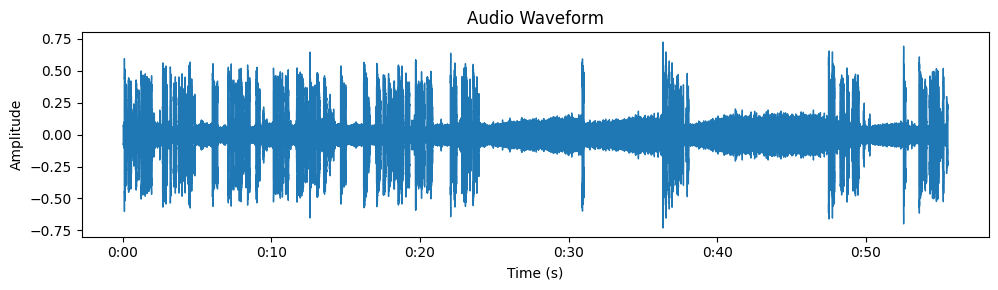

In [5]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title('Audio Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## 6. Load Alignment Model

Let's load the MMS-300m ASR model we're going to use.

In [6]:
import torch
from ctc_forced_aligner import (
    load_audio,
    load_alignment_model,
    generate_emissions,
    preprocess_text,
    get_alignments,
    get_spans,
    postprocess_results,
)

language = "eng" # ISO-639-3 Language code
device = "cuda" if torch.cuda.is_available() else "cpu"


alignment_model, alignment_tokenizer = load_alignment_model(
    device,
    model_path="MahmoudAshraf/mms-300m-1130-forced-aligner",
    dtype=torch.float16 if device == "cuda" else torch.float32,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/423 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

## 7. Word-Level Forced Alignment

Now, let's perform word-level forced alignment using our model.

We use dynamic programming to perform the alignment. A simple representation of how the algorithm works is provided here.
![Alternative Text](https://i.ibb.co/fm05cnw/nfa-forced-alignment-pipeline3.png)

In [7]:
# 1. Load the audio file into a format compatible with the alignment model
audio_waveform = load_audio(audio_path, alignment_model.dtype, alignment_model.device)

# 2. Generate log-probability emissions from the model for the audio
emissions, stride = generate_emissions(
    alignment_model,
    audio_waveform,
)

# 3. Preprocess the transcript ('split_size' determines granularity, can be "sentence" or even "char")
tokens_starred, text_starred = preprocess_text(
    text,
    romanize=True,
    split_size="word",
    language=language,
)

# 4. Find the optimal alignment between emissions and tokens
segments, scores, blank_token = get_alignments(
    emissions,
    tokens_starred,
    alignment_tokenizer,
)

# 5. Group the frame-level segments into spans
spans = get_spans(tokens_starred, segments, blank_token)

# 6. Convert spans into human-readable timestamps (start/end times in seconds)
word_timestamps = postprocess_results(text_starred, spans, stride, scores)

/usr/local/lib/python3.12/dist-packages/ctc_forced_aligner/alignment_utils.py:139: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1581.)
  return torch.frombuffer(out, dtype=torch.int16).flatten().to(dtype).to(device) / 32768.0


In [8]:
# Display results
for elem in word_timestamps[-10:]:
    start = elem["start"]
    end = elem["end"]
    word = elem["text"]
    print(f"Word: {word} | Start: {start} | End: {end}")
    display(Audio(y[int(start*sr):int(end*sr)], rate=sr))

Word: one | Start: 47.7 | End: 47.98


Word: small | Start: 48.08 | End: 48.48


Word: step | Start: 48.56 | End: 48.86


Word: for | Start: 49.0 | End: 49.12


Word: man, | Start: 49.18 | End: 49.56


Word: one | Start: 52.58 | End: 52.76


Word: giant | Start: 53.66 | End: 53.8


Word: leap | Start: 53.88 | End: 54.12


Word: for | Start: 54.2 | End: 54.38


Word: mankind. | Start: 54.5 | End: 55.5


## 8. Conclusion

In this tutorial, you've:

1. Understood what forced alignment is and why it's useful
2. Used the MMS model to perform word-level alignment on an audio clip and its corresponding transcription
3. Visualized the results word by word

This technique can be applied to any language supported by the model and is useful for many applications including subtitling, language learning, and audio editing.